# Coupling Flow with Mixture-CDF Transform

The first notebook trained a Gaussianization flow by stacking *unconditional* marginal layers (mixture CDF per dim) and rotations. The marginal layers can only Gaussianize each dimension independently; cross-dimensional structure is left entirely to the rotations.

A **coupling layer** (Real NVP, 2016) replaces that with a *conditional* transform. Given a mask $m \in \{0, 1\}^d$:

1. Split $x = (x_a, x_b)$ with $x_a$ the identity half (mask True) and $x_b$ the transformed half (mask False).
2. A *conditioner* network $\theta(x_a)$ outputs the mixture parameters $(\pi, \mu, \log\sigma)$ for each dimension in $x_b$.
3. Apply the mixture-CDF Gaussianization to $x_b$ using those *per-example* parameters: $z_b = \Phi^{-1}(F(x_b; \theta(x_a)))$.
4. Leave $z_a = x_a$ unchanged.

Since the Jacobian is lower triangular, the log-det is just the sum of per-b-dim diagonal contributions — same form as the unconditional marginal layer, but now the distribution of $z_b$ depends on $x_a$, so cross-dimensional structure is learnt directly. We pair two coupling layers with swapped masks inside each block so both halves get transformed.

## Mathematical structure

### Notation and shapes

Throughout: batch dimension $N$, input dimensionality $d$, mixture components $K$.

- **Mask** $m \in \{0, 1\}^d$. With default "half" for $d = 2$ we have $m = [1, 0]$, so $d_a = 1$ dim passes through, $d_b = 1$ dim gets transformed. The `mask=True` set is the **identity** side $a$; `mask=False` is the **transformed** side $b$.
- **Split**: $x \in \mathbb{R}^{N \times d}$ splits into $x_a \in \mathbb{R}^{N \times d_a}$ and $x_b \in \mathbb{R}^{N \times d_b}$.

### The bijector — GMM per b-dim

Each transformed dimension $i \in b$ has its own per-example mixture of $K$ Gaussians,
$$F_i(x_{b,i};\,\pi_i, \mu_i, \sigma_i) \;=\; \sum_{k=1}^{K} \pi_{i,k}\,\Phi\!\big((x_{b,i} - \mu_{i,k})/\sigma_{i,k}\big),$$
and the per-b-dim forward is exactly the mixture-CDF Gaussianization from notebook 01 — the **same** primitive, only difference is that $(\pi_i, \mu_i, \sigma_i)$ now depend on $x_a$:
$$z_{b,i} \;=\; \Phi^{-1}\!\big(F_i(x_{b,i};\,\theta_i(x_a))\big).$$
The per-example parameter tensors have shape $(N, d_b, K)$.

### The conditioner — a residual MLP with a zero-init head

The conditioner is any `keras.Layer` taking $x_a \in \mathbb{R}^{d_a}$ and producing $3 \cdot d_b \cdot K$ floats (packed logits, means, raw log-scales). We use two concrete builders:
- `make_mlp_conditioner(d_b, K, hidden=(64, 64))` — plain MLP with a zero-initialised final Dense so the flow starts at identity.
- `make_shared_mlp_conditioner(d_b, K, hidden=(64, 64))` — one $(3 \cdot K)$-wide head tiled across all $d_b$ b-dims. Cheaper, less expressive.

Section 9 shows a **residual** variant — one hidden block with a skip connection,
$$\phi(x_a) \;=\; \tanh\!\big(W_2 \tanh(W_1 x_a + b_1) + b_2\big) \;+\; \tanh(W_1 x_a + b_1), \quad \theta(x_a) \;=\; W_{\text{out}}\,\phi(x_a) + c.$$
All three builders plug into `MixtureCDFCoupling` interchangeably because the coupling layer only cares about the output width ($= 3 \cdot d_b \cdot K$, enforced by a build-time check).

### Log-scale clamp

Raw conditioner outputs for $\log \sigma$ are passed through a bounded map before being exponentiated,
$$\log \sigma_{i,k} \;=\; B\,\tanh(\tilde{\log\sigma}_{i,k}),$$
with default $B = 3$ so $\sigma \in [e^{-3}, e^3] \approx [0.05, 20]$. This keeps scales from blowing up or collapsing during training, especially when the conditioner is still warming up.

### Jacobian of the coupling layer

With $z_a = x_a$ and $z_b = \Phi^{-1}(F(x_b;\,\theta(x_a)))$, the Jacobian is block-triangular:
$$J \;=\; \begin{pmatrix} I_{d_a} & 0 \\ \ast & \mathrm{diag}(\partial z_{b,i} / \partial x_{b,i}) \end{pmatrix},
\qquad \log\lvert\det J\rvert \;=\; \sum_{i \in b} \log\lvert \partial z_{b,i} / \partial x_{b,i} \rvert.$$
The lower-left off-diagonal depends on $\partial \theta(x_a)/\partial x_a$ (the conditioner Jacobian) but that block doesn't enter the determinant — only the diagonal of the bottom-right matters. Same diagonal-log-det structure as the unconditional layer.

### Comparison to classical Real NVP (affine coupling)

Real NVP / Glow use an **affine** coupling,
$$z_b \;=\; x_b \odot \exp\!\big(s(x_a)\big) + t(x_a).$$
Our layer uses a **mixture-CDF** coupling — strictly more expressive per-b-dim (can handle multimodal conditional distributions), same diagonal-Jacobian structure, same cost.

### Mask-swap pair per block

A single coupling layer only transforms the $b$-dim half. One block therefore uses *two* coupling layers with swapped masks `[m, ~m]` so **both** halves get touched. The rotation sitting at the start of the block mixes information across dims before the pair fires.

In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from keras import ops
from sklearn.datasets import make_moons

from gaussianization.gauss_keras import (
    base_nll_loss,
    make_coupling_flow,
)

# --- global plot styling ------------------------------------------------------
sns.set_theme(context="poster", style="whitegrid", palette="deep", font_scale=0.85)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 110,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.2,
        "figure.constrained_layout.use": True,
        "figure.constrained_layout.h_pad": 0.1,
        "figure.constrained_layout.w_pad": 0.1,
        "axes.grid.which": "both",
        "grid.linewidth": 0.7,
        "grid.alpha": 0.5,
        "axes.edgecolor": "0.25",
        "axes.linewidth": 1.1,
        "axes.titleweight": "semibold",
        "axes.labelpad": 6,
    }
)


def style_axes(ax, *, aspect=None, grid=True):
    if grid:
        ax.minorticks_on()
        ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
        ax.grid(True, which="minor", linewidth=0.4, alpha=0.3)
    if aspect is not None:
        ax.set_aspect(aspect)
    return ax


def style_jointgrid(g, aspect="equal"):
    style_axes(g.ax_joint, aspect=aspect)
    style_axes(g.ax_marg_x, grid=False)
    style_axes(g.ax_marg_y, grid=False)
    for spine in ("top", "right"):
        g.ax_marg_x.spines[spine].set_visible(False)
        g.ax_marg_y.spines[spine].set_visible(False)


palette = sns.color_palette("deep")

keras.utils.set_random_seed(0)
np.random.seed(0)

I0000 00:00:1776869571.422244  410267 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 1. Dataset
Same two-moons dataset as in notebook 01 so the comparison is clean.

/home/azureuser/.cache/uv/archive-v0/aYSeLZUlluhRY4DCBNG7F/lib/python3.13/site-packages/seaborn/axisgrid.py:1766: UserWarning: The figure layout has changed to tight
  f.tight_layout()


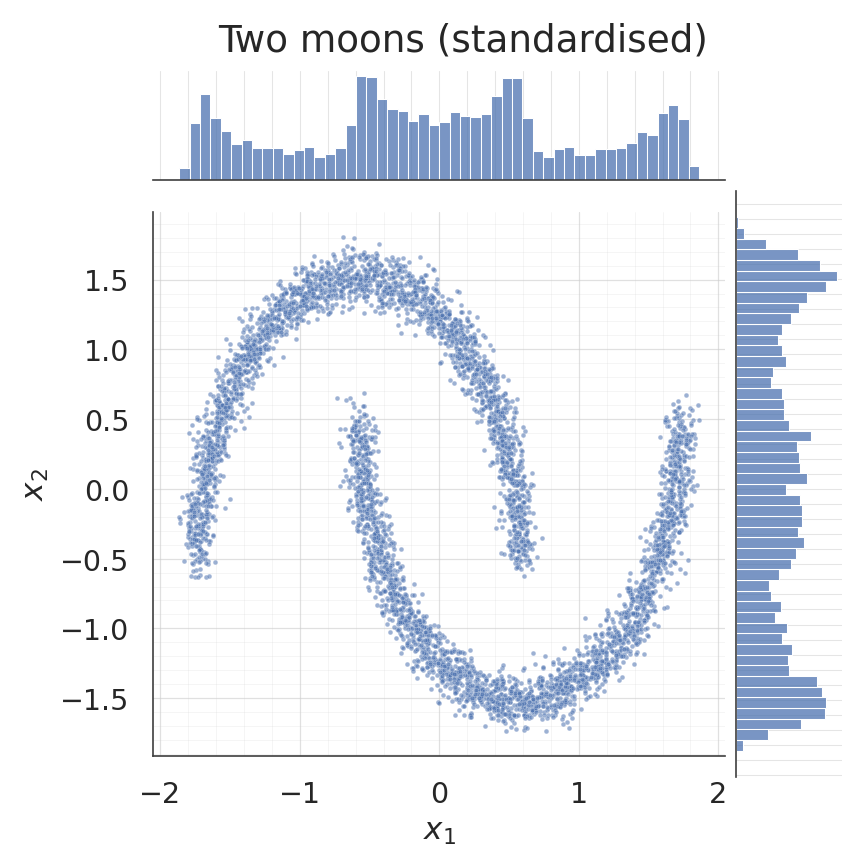

In [2]:
X_raw, _ = make_moons(n_samples=5000, noise=0.05, random_state=0)
X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
X = X.astype("float32")

g = sns.jointplot(
    x=X[:, 0], y=X[:, 1], kind="scatter", color=palette[0],
    height=7.5, ratio=5, space=0.1,
    joint_kws={"s": 10, "alpha": 0.55},
    marginal_kws={"bins": 50, "color": palette[0], "alpha": 0.75, "edgecolor": "white"},
)
g.set_axis_labels("$x_1$", "$x_2$")
g.figure.suptitle("Two moons (standardised)", y=1.02)
style_jointgrid(g)
plt.show()

## 2. Build a coupling flow

Each block is `[Householder, MixtureCDFCoupling(mask=m), MixtureCDFCoupling(mask=~m)]`. The two coupling layers with complementary masks together transform **all** dimensions; the Householder rotation mixes the already-transformed state before the next block.

With `d = 2`, `mask = [True, False]` means the first coupling layer conditions on dim 0 and transforms dim 1, and the second coupling layer (with swapped mask) conditions on dim 1 and transforms dim 0. The conditioner is a zero-initialised MLP, so the flow starts out as the identity and training is stable from step 0.

In [3]:
flow = make_coupling_flow(
    input_dim=2,
    num_blocks=4,
    num_components=8,
    hidden=(64, 64),
)

_ = flow(ops.convert_to_tensor(X[:4]))

n_coupling = sum(
    1 for b in flow.bijector_layers if b.__class__.__name__ == "MixtureCDFCoupling"
)
n_rot = sum(
    1 for b in flow.bijector_layers if b.__class__.__name__ == "Householder"
)
n_params = int(sum(np.prod(w.shape) for w in flow.trainable_weights))
print(f"bijectors          : {len(flow.bijector_layers)}  "
      f"({n_rot} rotations, {n_coupling} coupling)")
print(f"trainable params   : {n_params}")

E0000 00:00:1776869576.712001  410267 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


bijectors          : 12  (4 rotations, 8 coupling)
trainable params   : 46800


## 3. Train

Same training recipe as the marginal-only flow (Adam, NLL loss, 200 epochs), so differences in the final density/pushforward are attributable to the coupling architecture.

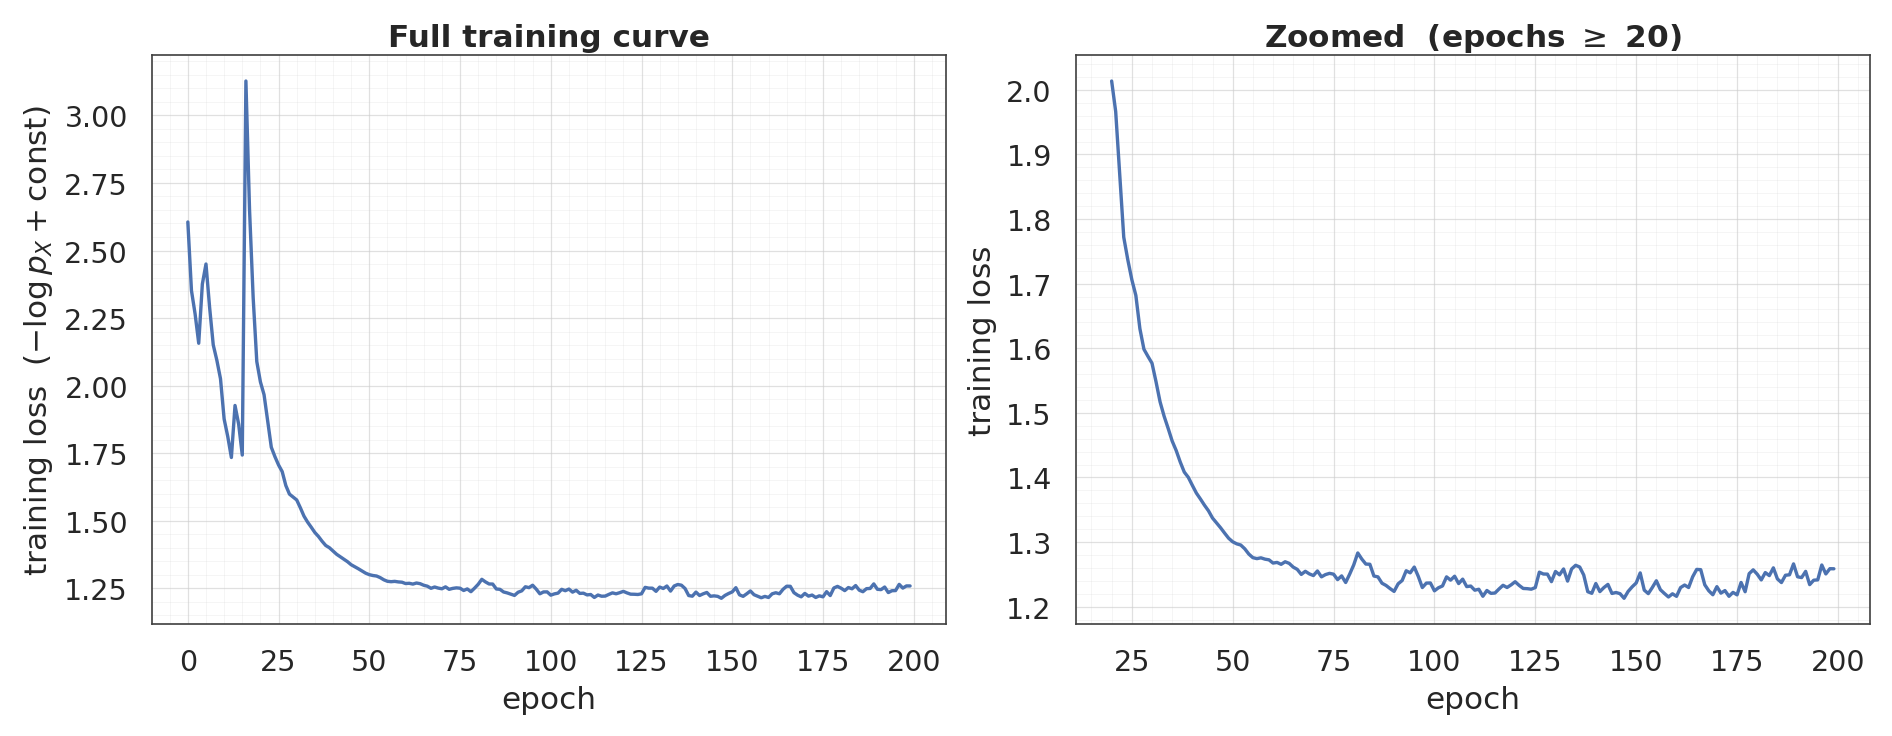

final loss: +1.2587   (min: +1.2130)


In [4]:
flow.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-3),
    loss=base_nll_loss,
)

history = flow.fit(X, X, batch_size=512, epochs=200, verbose=0)
loss_curve = np.asarray(history.history["loss"])

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
c = palette[0]

ax = axes[0]
ax.plot(loss_curve, color=c, linewidth=2.2)
ax.set_xlabel("epoch")
ax.set_ylabel("training loss  $(-\\log p_X + \\text{const})$")
ax.set_title("Full training curve")
style_axes(ax)

ax = axes[1]
tail_start = 20
tail = loss_curve[tail_start:]
ax.plot(range(tail_start, len(loss_curve)), tail, color=c, linewidth=2.2)
span = tail.max() - tail.min()
ax.set_ylim(tail.min() - 0.05 * span, tail.max() + 0.05 * span)
ax.set_xlabel("epoch")
ax.set_ylabel("training loss")
ax.set_title(f"Zoomed  (epochs $\\geq$ {tail_start})")
style_axes(ax)

plt.show()
print(f"final loss: {loss_curve[-1]:+.4f}   (min: {loss_curve.min():+.4f})")

## 4. Pushforward and density

The pushforward $z = f(x)$ should be approximately $\mathcal{N}(0, I)$. A jointplot puts the 2-D scatter next to the per-dim marginals; the black reference curves are $\varphi(z)$.

Unlike a marginal-only flow, here the conditioner can express the cross-dim dependence exactly (each $z_b$ is conditional on $x_a$) — the density contour in $x$-space should trace the two moons sharply.

pushforward diagnostics
  mean:      [+0.086, -0.090]   target = [0, 0]
  cov[0,0]:  0.948                  target = 1
  cov[1,1]:  1.150                  target = 1
  cov[0,1]:  +0.127                  target = 0


/home/azureuser/.cache/uv/archive-v0/aYSeLZUlluhRY4DCBNG7F/lib/python3.13/site-packages/seaborn/axisgrid.py:1766: UserWarning: The figure layout has changed to tight
  f.tight_layout()


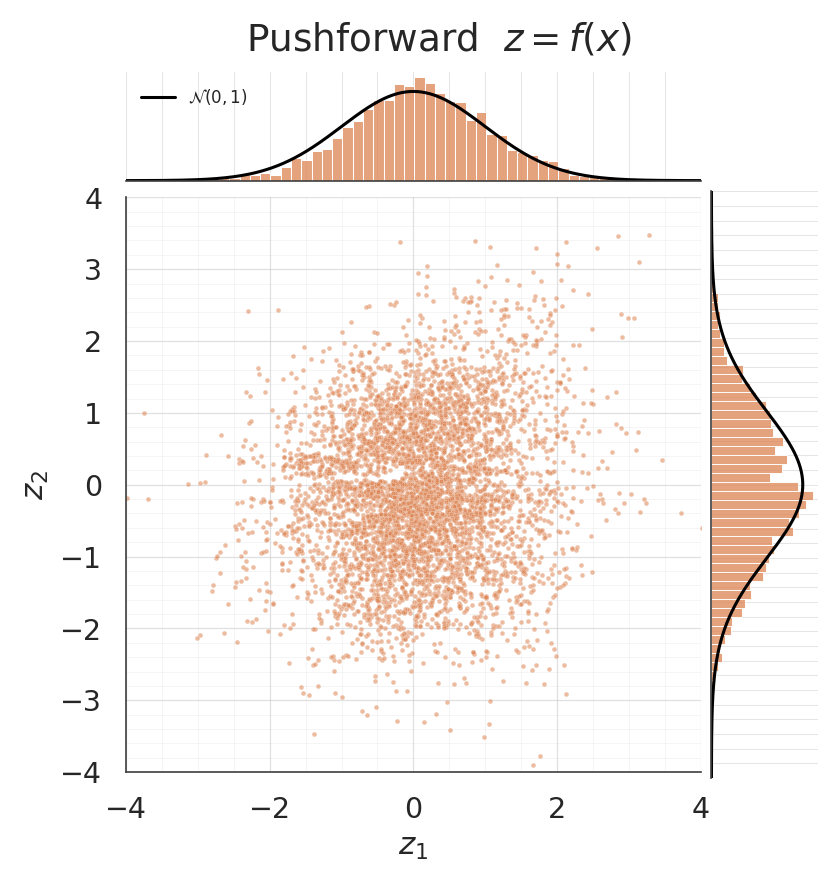

In [5]:
z = ops.convert_to_numpy(flow(ops.convert_to_tensor(X)))
mean_z = z.mean(axis=0)
cov_z = np.cov(z, rowvar=False)
print("pushforward diagnostics")
print(f"  mean:      [{mean_z[0]:+.3f}, {mean_z[1]:+.3f}]   target = [0, 0]")
print(f"  cov[0,0]:  {cov_z[0, 0]:.3f}                  target = 1")
print(f"  cov[1,1]:  {cov_z[1, 1]:.3f}                  target = 1")
print(f"  cov[0,1]:  {cov_z[0, 1]:+.3f}                  target = 0")

g = sns.jointplot(
    x=z[:, 0], y=z[:, 1], kind="scatter", color=palette[1],
    height=7.5, ratio=5, space=0.1,
    joint_kws={"s": 10, "alpha": 0.55},
    marginal_kws={
        "bins": 60, "color": palette[1], "alpha": 0.75,
        "edgecolor": "white", "stat": "density",
    },
    xlim=(-4, 4), ylim=(-4, 4),
)
zz = np.linspace(-4, 4, 300)
phi = np.exp(-0.5 * zz**2) / np.sqrt(2 * np.pi)
g.ax_marg_x.plot(zz, phi, color="black", linewidth=2.0, label="$\\mathcal{N}(0, 1)$")
g.ax_marg_y.plot(phi, zz, color="black", linewidth=2.0)
g.ax_marg_x.legend(loc="upper left", frameon=False, fontsize=11)
g.set_axis_labels("$z_1$", "$z_2$")
g.figure.suptitle("Pushforward  $z = f(x)$", y=1.02)
style_jointgrid(g)
plt.show()

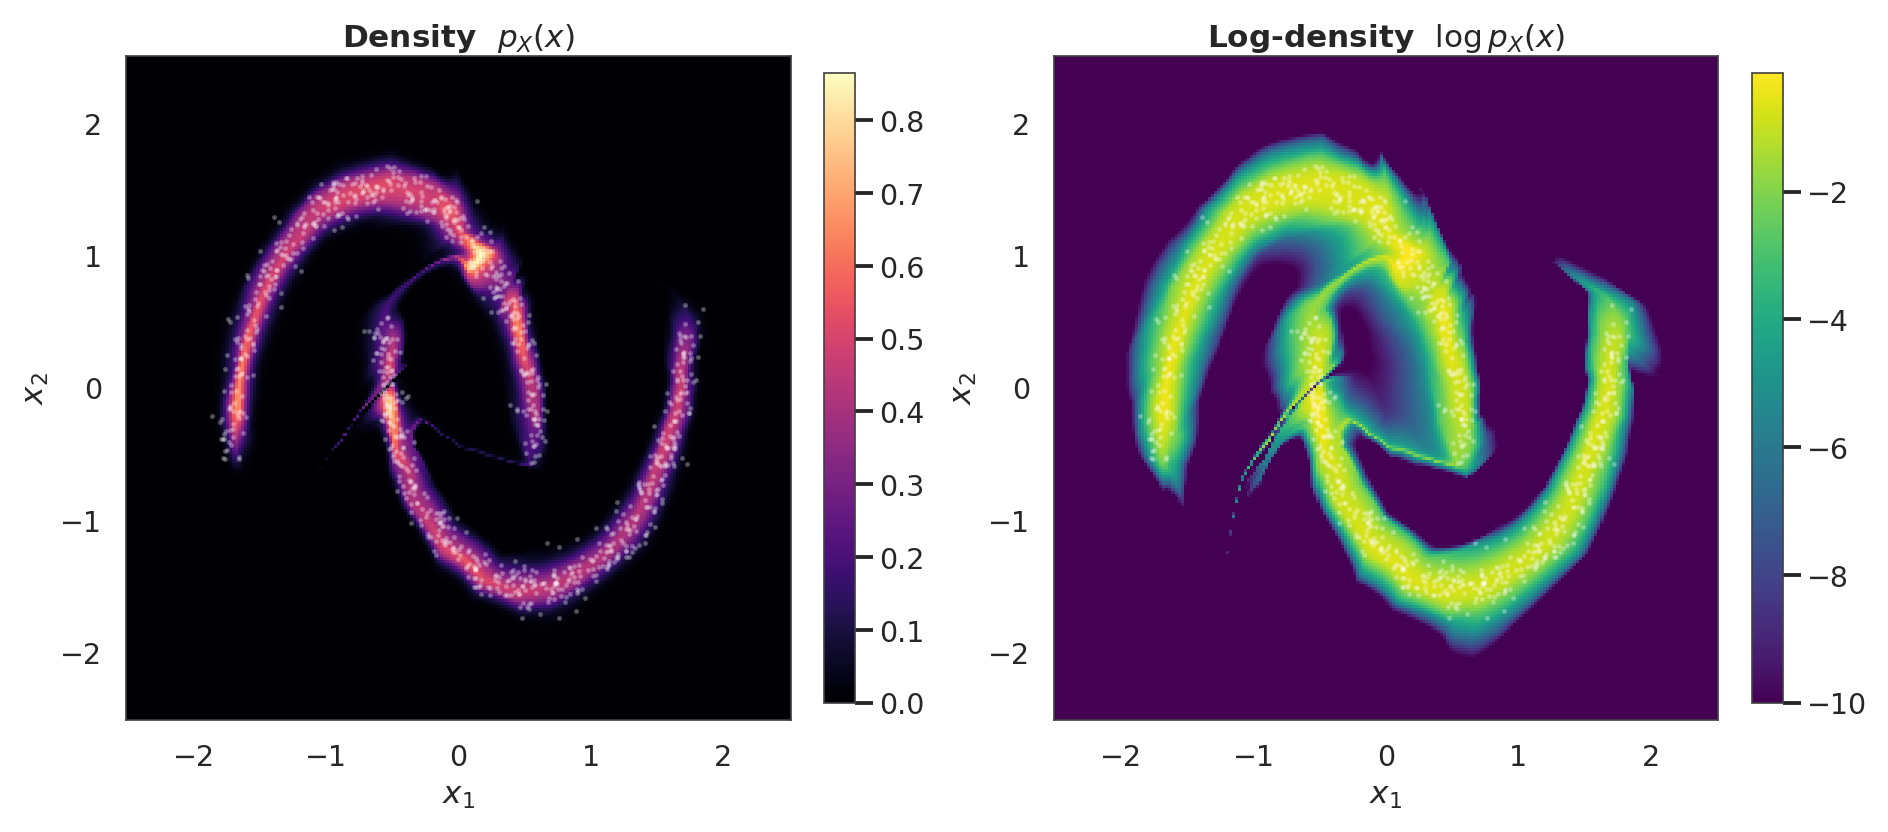

In [6]:
grid = 220
xs = np.linspace(-2.5, 2.5, grid).astype("float32")
ys = np.linspace(-2.5, 2.5, grid).astype("float32")
xx, yy = np.meshgrid(xs, ys)
pts = np.stack([xx.ravel(), yy.ravel()], axis=-1).astype("float32")
log_px = ops.convert_to_numpy(flow.log_prob(ops.convert_to_tensor(pts))).reshape(grid, grid)

fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))

ax = axes[0]
pcm = ax.pcolormesh(xx, yy, np.exp(log_px), cmap="magma", shading="auto")
ax.scatter(X[:1000, 0], X[:1000, 1], s=2, alpha=0.25, color="white")
ax.set_title("Density  $p_X(x)$")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
style_axes(ax, aspect="equal")
fig.colorbar(pcm, ax=ax, shrink=0.85)

ax = axes[1]
pcm = ax.pcolormesh(xx, yy, np.clip(log_px, -10, None), cmap="viridis", shading="auto")
ax.scatter(X[:1000, 0], X[:1000, 1], s=2, alpha=0.25, color="white")
ax.set_title("Log-density  $\\log p_X(x)$")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
style_axes(ax, aspect="equal")
fig.colorbar(pcm, ax=ax, shrink=0.85)
plt.show()

## 5. Sampling from the flow

$z \sim \mathcal{N}(0, I) \mapsto x = f^{-1}(z)$. Each coupling layer's inverse bisects $F(x_b; \theta(z_a)) = \Phi(z_b)$ per b-dim, with $z_a = x_a$ preserved through the layer so the conditioner sees the same input in both directions.

/home/azureuser/.cache/uv/archive-v0/aYSeLZUlluhRY4DCBNG7F/lib/python3.13/site-packages/seaborn/axisgrid.py:1766: UserWarning: The figure layout has changed to tight
  f.tight_layout()


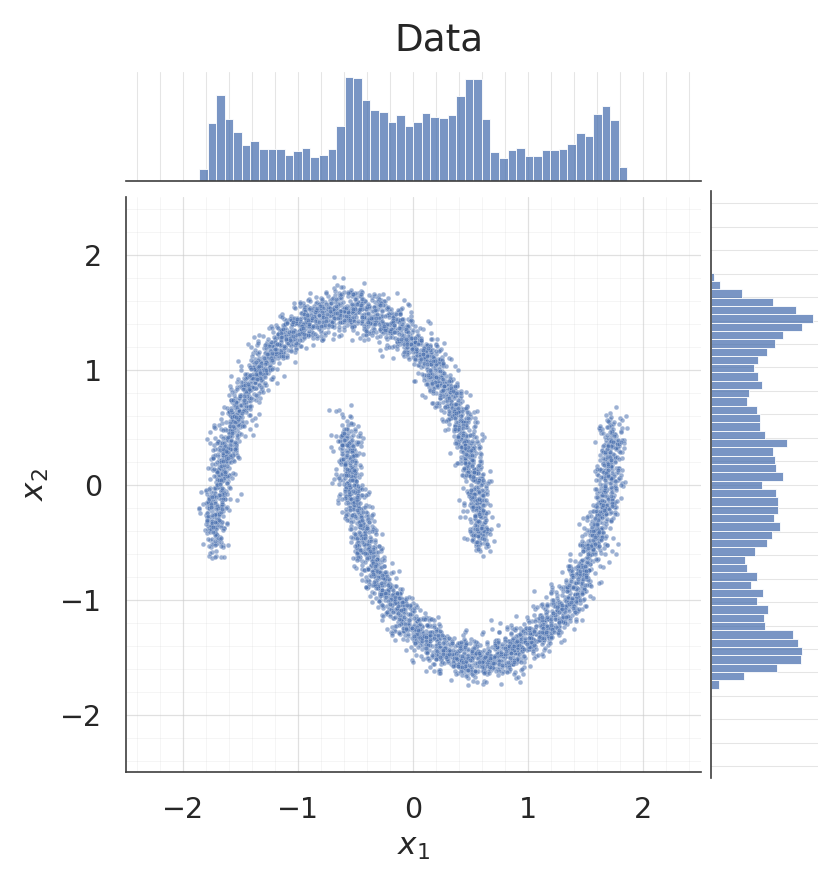

/home/azureuser/.cache/uv/archive-v0/aYSeLZUlluhRY4DCBNG7F/lib/python3.13/site-packages/seaborn/axisgrid.py:1766: UserWarning: The figure layout has changed to tight
  f.tight_layout()


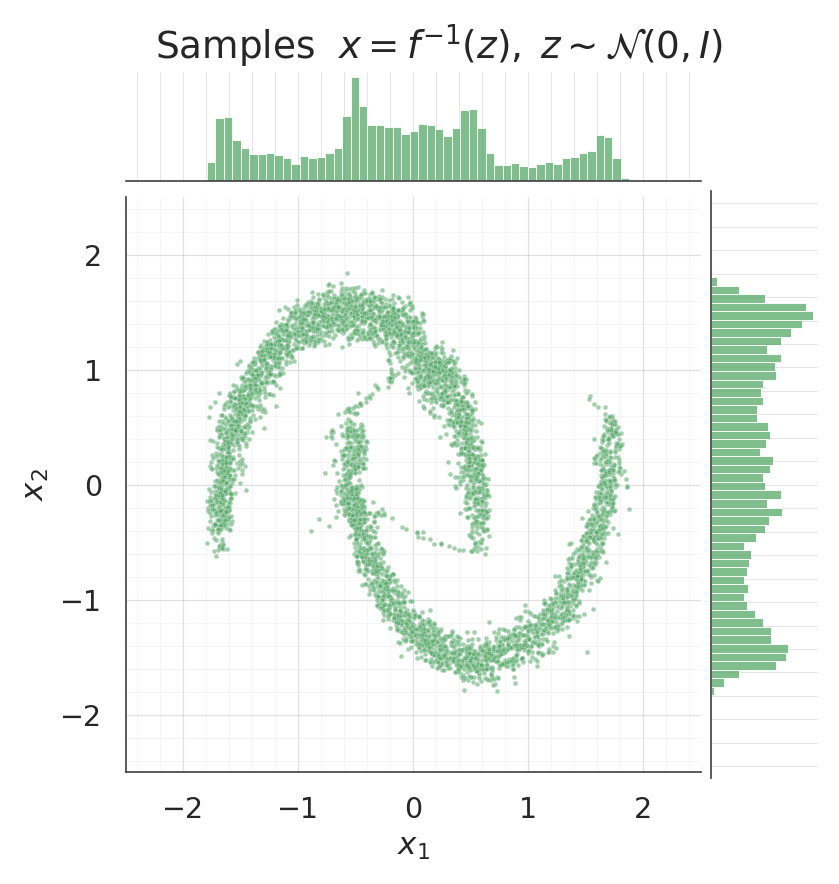

In [7]:
samples = ops.convert_to_numpy(flow.sample(num_samples=5000, seed=1))

for data, title, col in [
    (X, "Data", palette[0]),
    (samples, "Samples  $x = f^{-1}(z), \\; z \\sim \\mathcal{N}(0, I)$", palette[2]),
]:
    g = sns.jointplot(
        x=data[:, 0], y=data[:, 1], kind="scatter", color=col,
        height=7.5, ratio=5, space=0.1,
        joint_kws={"s": 10, "alpha": 0.55},
        marginal_kws={
            "bins": 50, "color": col, "alpha": 0.75,
            "edgecolor": "white",
        },
        xlim=(-2.5, 2.5), ylim=(-2.5, 2.5),
    )
    g.set_axis_labels("$x_1$", "$x_2$")
    g.figure.suptitle(title, y=1.02)
    style_jointgrid(g)
    plt.show()

## 6. Round-trip inversion

Each coupling layer is a bijection by construction, so $f^{-1}(f(x))$ should recover $x$ to numerical precision.

round-trip L2 error  ||f^{-1}(f(x)) - x||_2
  median : 1.55e-06
  95th%  : 7.06e-05
  max    : 1.20e-01


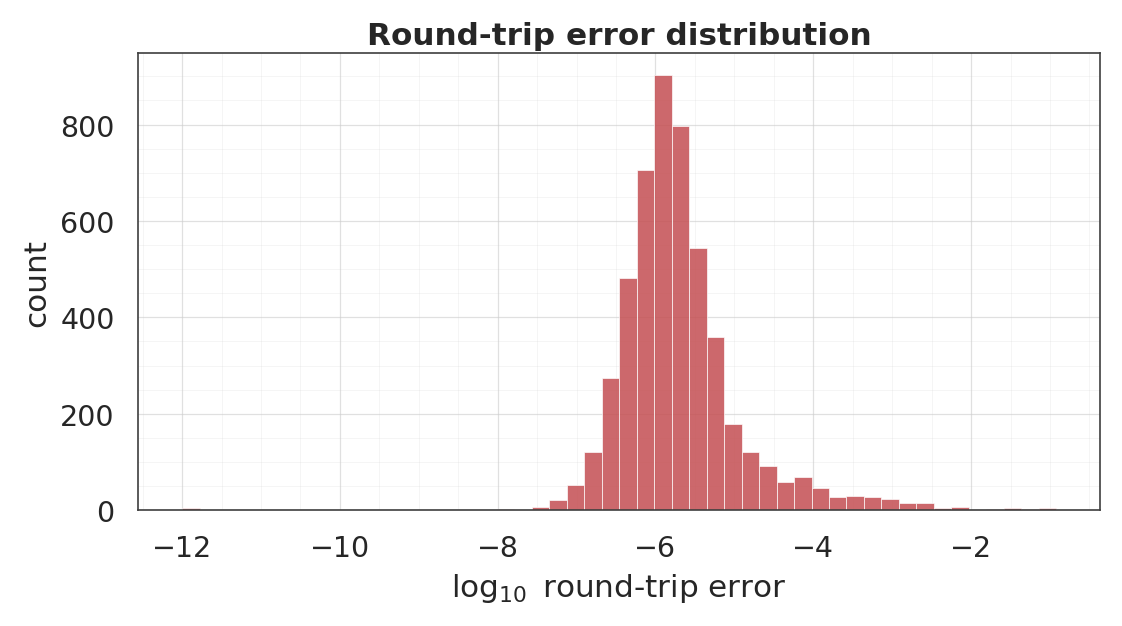

In [8]:
x_t = ops.convert_to_tensor(X)
z_fwd = flow(x_t)
x_rt = ops.convert_to_numpy(flow.invert(z_fwd))
err = np.linalg.norm(x_rt - X, axis=-1)
print("round-trip L2 error  ||f^{-1}(f(x)) - x||_2")
print(f"  median : {np.median(err):.2e}")
print(f"  95th%  : {np.percentile(err, 95):.2e}")
print(f"  max    : {err.max():.2e}")

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(
    np.log10(err + 1e-12), bins=50, color=palette[3],
    alpha=0.85, edgecolor="white", linewidth=0.5,
)
ax.set_xlabel("$\\log_{10}$ round-trip error")
ax.set_ylabel("count")
ax.set_title("Round-trip error distribution")
style_axes(ax)
plt.show()

## 7. Layer-by-layer view

States $x,\, f_1(x),\, \ldots,\, z$. Each coupling layer transforms one half while keeping the other intact (you can see the passthrough half pinned, the other half morphing). Rotations remix the state between coupling pairs.

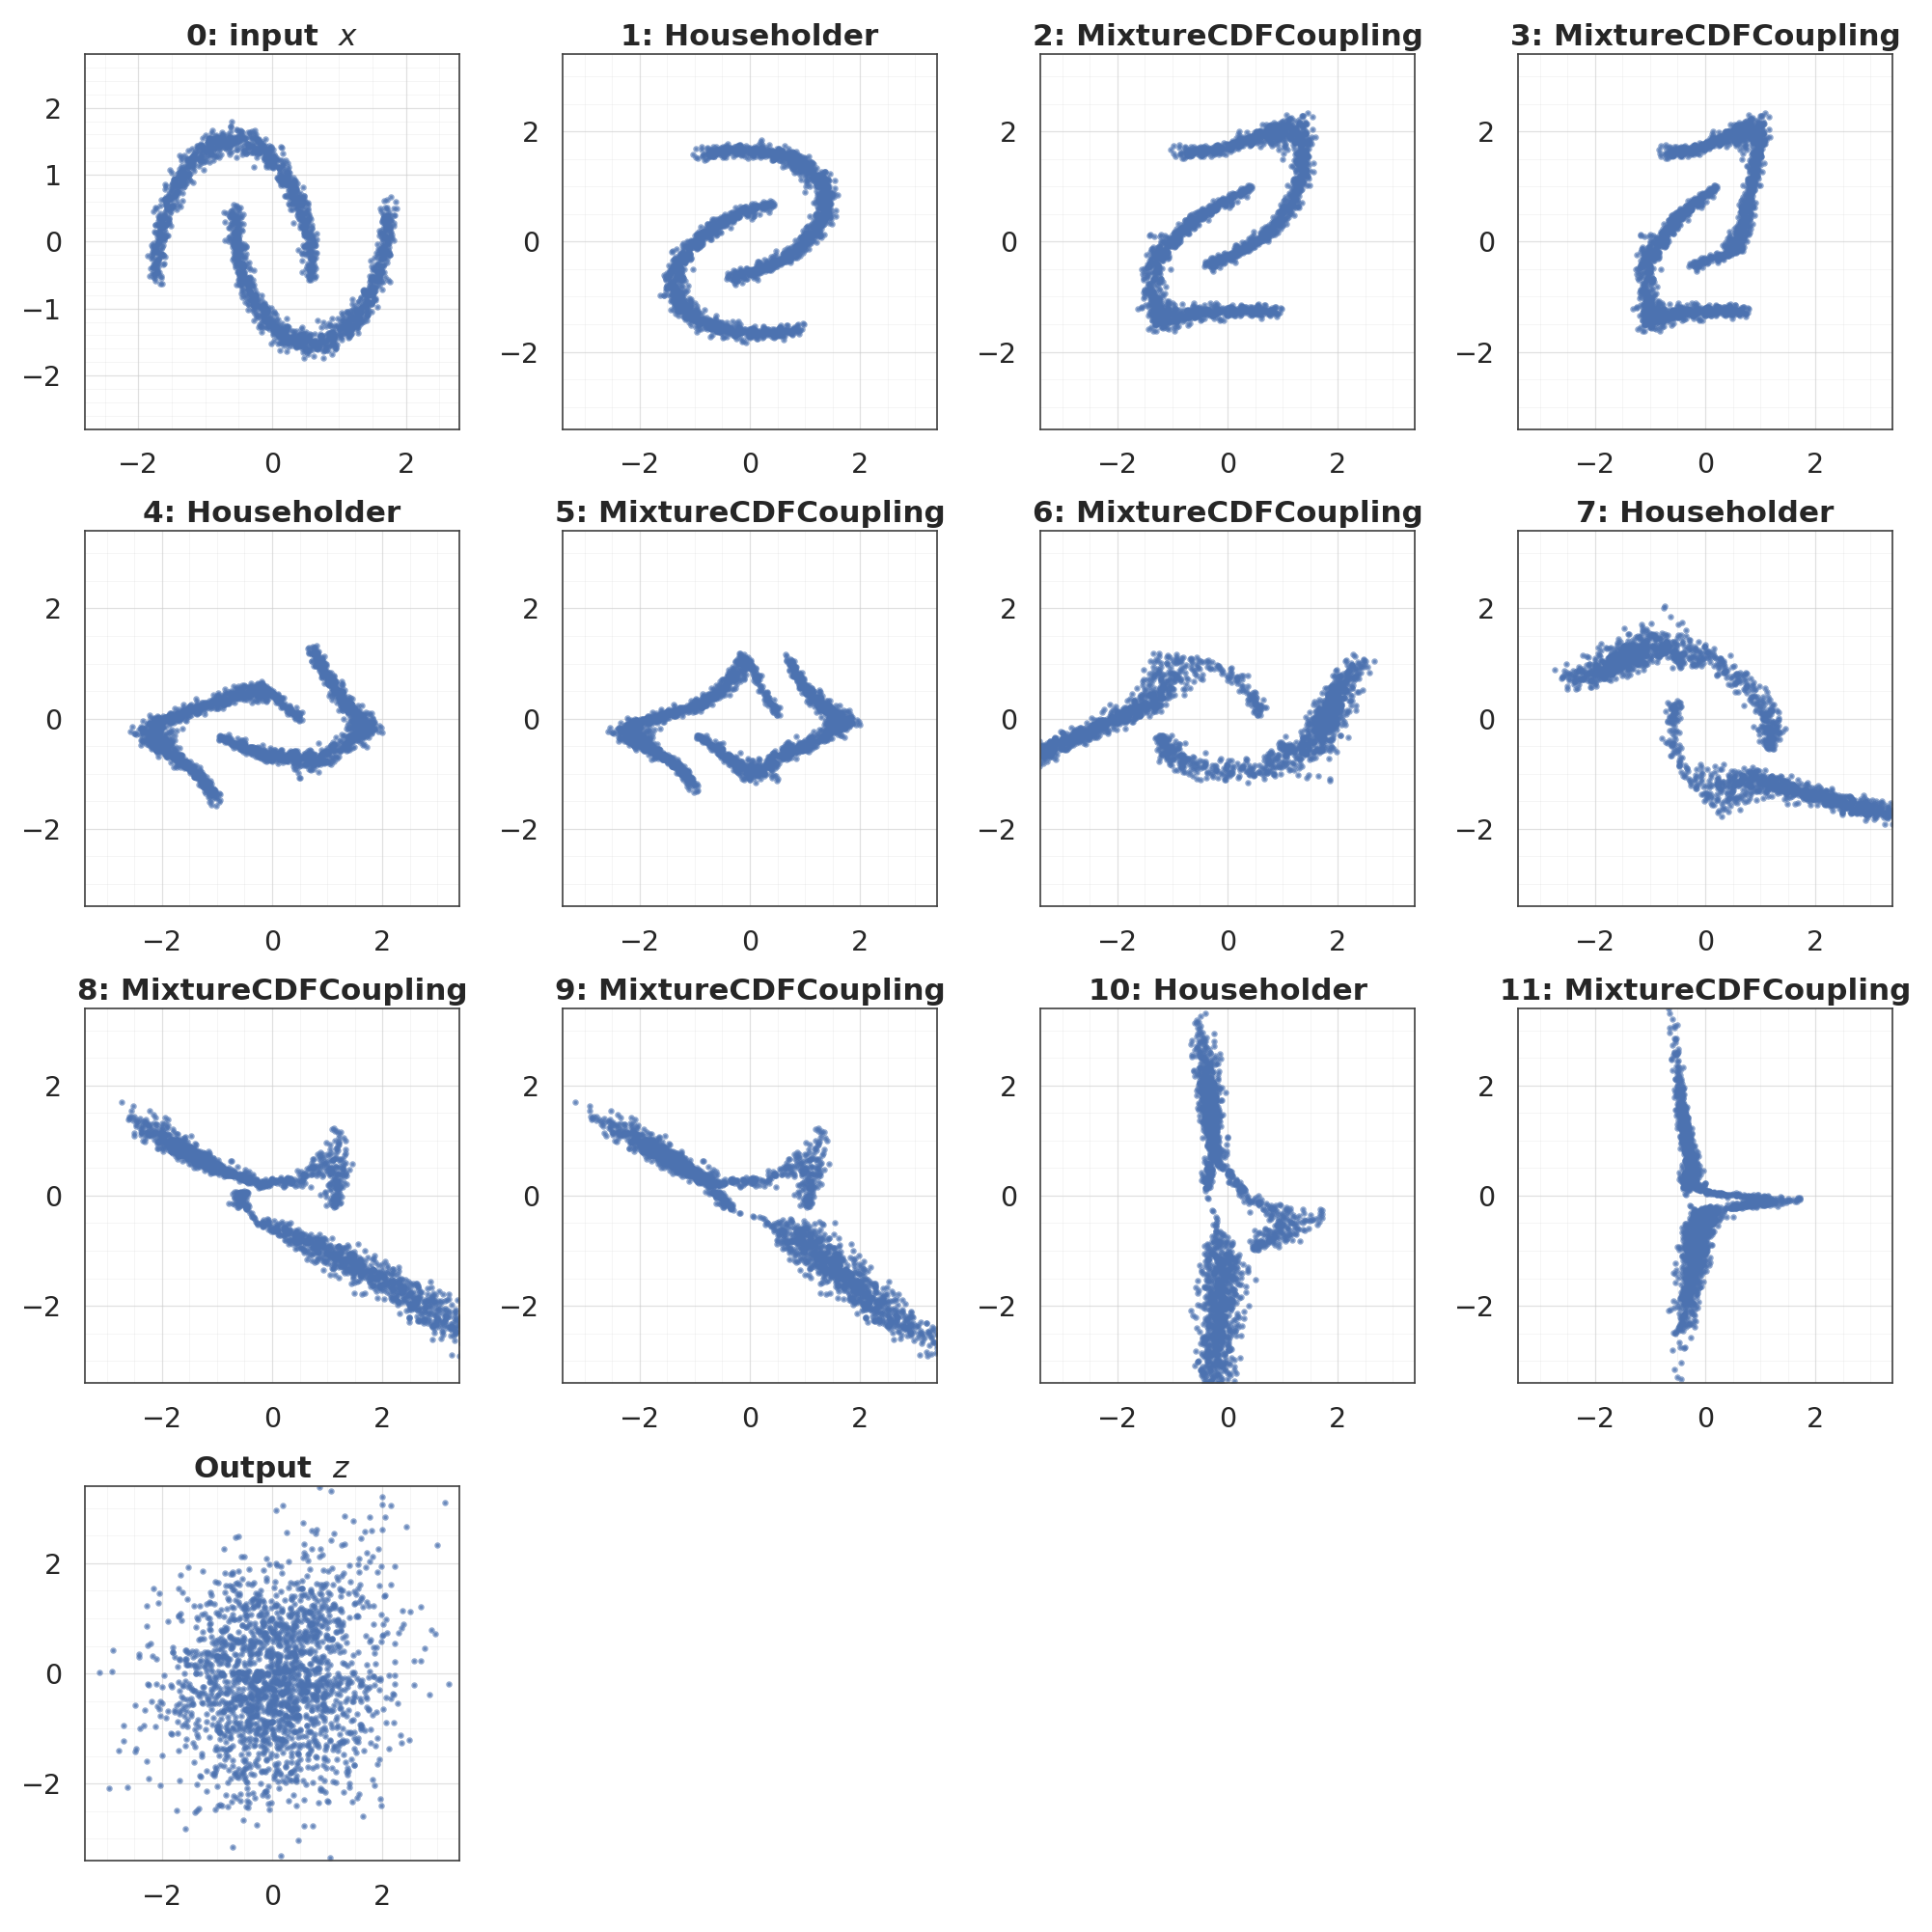

In [9]:
states = flow.forward_with_intermediates(ops.convert_to_tensor(X[:2000]))
states_np = [ops.convert_to_numpy(s) for s in states]
n_states = len(states_np)
ncol = 4
nrow = int(np.ceil(n_states / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.5 * ncol, 4.5 * nrow))
axes = axes.ravel()
layer_names = ["input  $x$"] + [
    b.__class__.__name__ for b in flow.bijector_layers
]
for i, (state, ax) in enumerate(zip(states_np, axes)):
    ax.scatter(state[:, 0], state[:, 1], s=5, alpha=0.6, color=palette[0])
    lim = 3.4 if i > 0 else 2.8
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    if i == n_states - 1:
        ax.set_title("Output  $z$")
    else:
        ax.set_title(f"{i}: {layer_names[i]}")
    style_axes(ax, aspect="equal")
for ax in axes[n_states:]:
    ax.axis("off")
plt.show()

## 8. Shared-mixture conditioner

The per-dim conditioner emits $3 \cdot d_b \cdot K$ floats — one mixture per transformed dimension. A **shared-mixture** conditioner emits only $3 \cdot K$ floats and reuses (tiles) those parameters across all $d_b$ dims. It is cheaper but strictly less expressive: every b-dim sees the same mixture given the same $x_a$.

For two-moons ($d = 2$, $d_b = 1$) the two are equivalent (only one b-dim per mask anyway). To see the difference we'd want $d \geq 3$; here we just verify it trains and recovers the same density to similar fidelity.

shared-mixture flow trainable params : 46800  (per-dim reference : 46800)


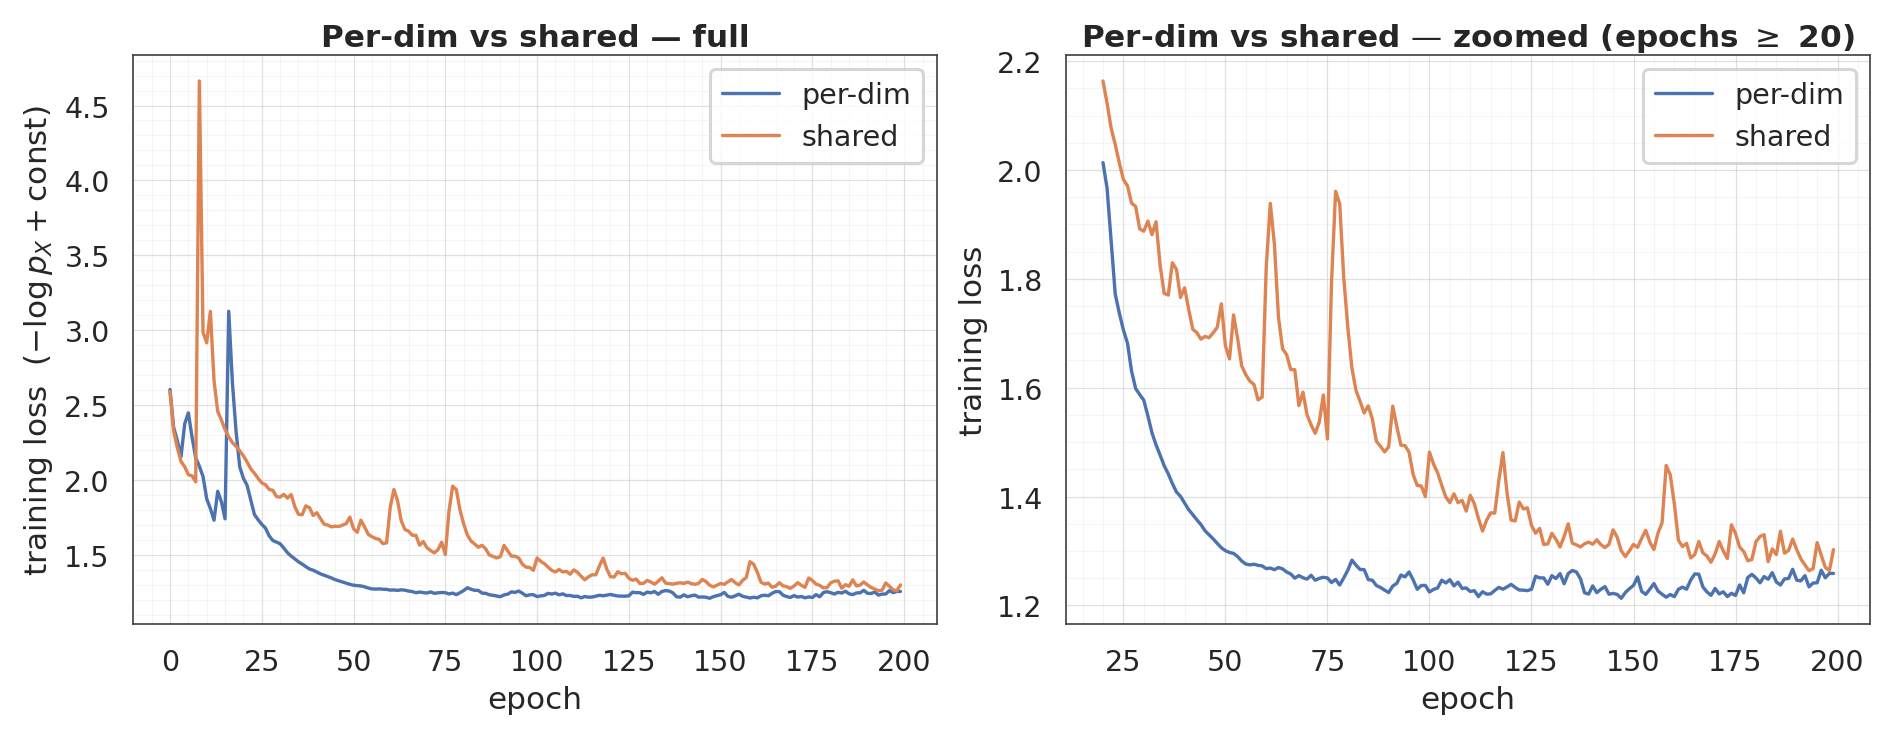

In [10]:
flow_shared = make_coupling_flow(
    input_dim=2,
    num_blocks=4,
    num_components=8,
    hidden=(64, 64),
    shared_mixture=True,
)
_ = flow_shared(ops.convert_to_tensor(X[:4]))
n_shared_params = int(sum(np.prod(w.shape) for w in flow_shared.trainable_weights))
print(f"shared-mixture flow trainable params : {n_shared_params}  "
      f"(per-dim reference : {n_params})")

flow_shared.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-3),
    loss=base_nll_loss,
)
history_shared = flow_shared.fit(X, X, batch_size=512, epochs=200, verbose=0)
shared_curve = np.asarray(history_shared.history["loss"])

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))

ax = axes[0]
ax.plot(loss_curve, label="per-dim", color=palette[0], linewidth=2.2)
ax.plot(shared_curve, label="shared", color=palette[1], linewidth=2.2)
ax.set_xlabel("epoch")
ax.set_ylabel("training loss  $(-\\log p_X + \\text{const})$")
ax.set_title("Per-dim vs shared — full")
ax.legend(frameon=True)
style_axes(ax)

ax = axes[1]
tail_start = 20
both_tail = np.concatenate([loss_curve[tail_start:], shared_curve[tail_start:]])
span = both_tail.max() - both_tail.min()
ax.plot(range(tail_start, len(loss_curve)), loss_curve[tail_start:],
        label="per-dim", color=palette[0], linewidth=2.2)
ax.plot(range(tail_start, len(shared_curve)), shared_curve[tail_start:],
        label="shared", color=palette[1], linewidth=2.2)
ax.set_ylim(both_tail.min() - 0.05 * span, both_tail.max() + 0.05 * span)
ax.set_xlabel("epoch")
ax.set_ylabel("training loss")
ax.set_title(f"Per-dim vs shared — zoomed (epochs $\\geq$ {tail_start})")
ax.legend(frameon=True)
style_axes(ax)

plt.show()

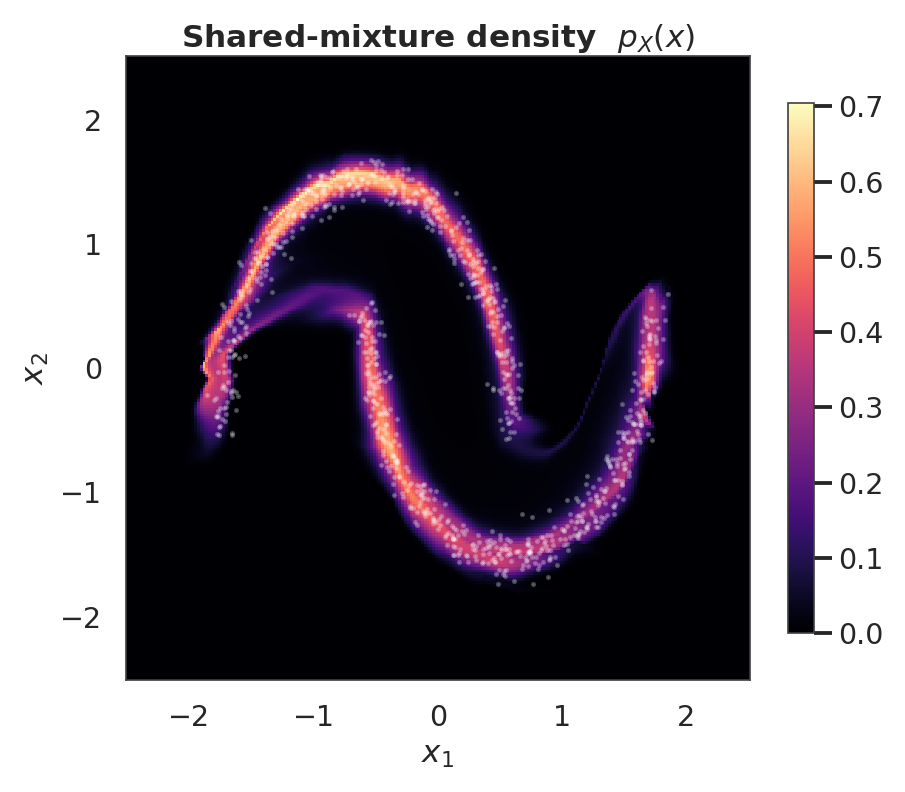

/home/azureuser/.cache/uv/archive-v0/aYSeLZUlluhRY4DCBNG7F/lib/python3.13/site-packages/seaborn/axisgrid.py:1766: UserWarning: The figure layout has changed to tight
  f.tight_layout()


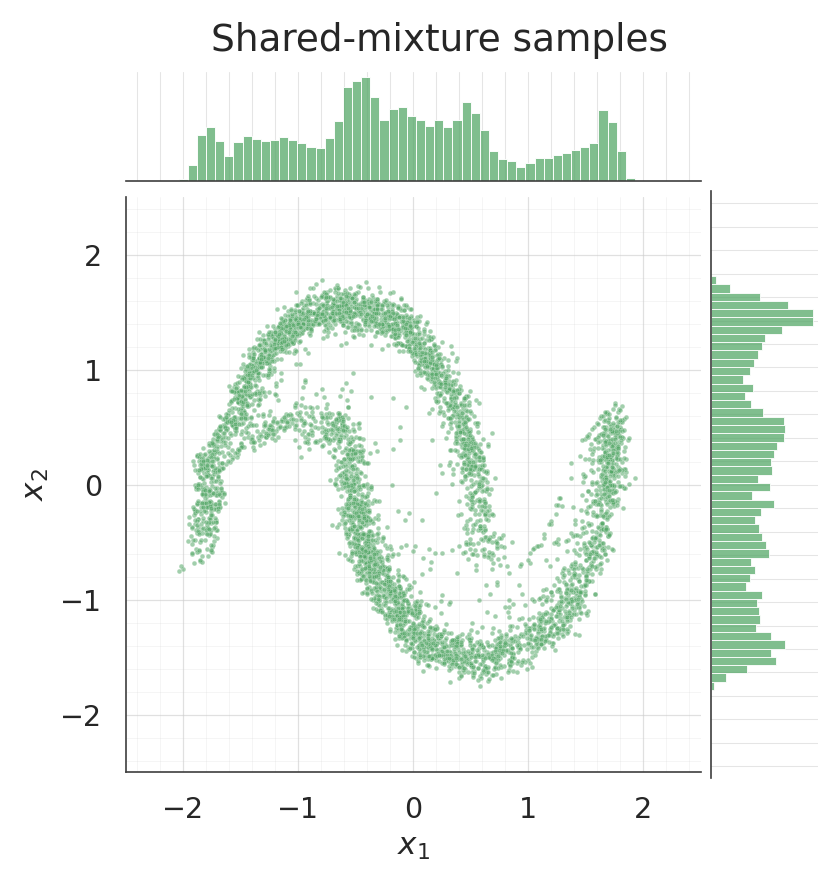

In [11]:
log_px_shared = ops.convert_to_numpy(
    flow_shared.log_prob(ops.convert_to_tensor(pts))
).reshape(grid, grid)

fig, ax = plt.subplots(figsize=(8.5, 7))
pcm = ax.pcolormesh(xx, yy, np.exp(log_px_shared), cmap="magma", shading="auto")
ax.scatter(X[:1000, 0], X[:1000, 1], s=2, alpha=0.25, color="white")
ax.set_title("Shared-mixture density  $p_X(x)$")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
style_axes(ax, aspect="equal")
fig.colorbar(pcm, ax=ax, shrink=0.85)
plt.show()

samples_shared = ops.convert_to_numpy(flow_shared.sample(num_samples=5000, seed=2))
g = sns.jointplot(
    x=samples_shared[:, 0], y=samples_shared[:, 1], kind="scatter", color=palette[2],
    height=7.5, ratio=5, space=0.1,
    joint_kws={"s": 10, "alpha": 0.55},
    marginal_kws={"bins": 50, "color": palette[2], "alpha": 0.75, "edgecolor": "white"},
    xlim=(-2.5, 2.5), ylim=(-2.5, 2.5),
)
g.set_axis_labels("$x_1$", "$x_2$")
g.figure.suptitle("Shared-mixture samples", y=1.02)
style_jointgrid(g)
plt.show()

## 9. Custom conditioner — bring your own (residual network)

The coupling layer accepts any Keras layer/model whose output width is exactly $3 \cdot d_b \cdot K$. The build-time correctness check enforces this and raises a descriptive error otherwise. Below is the residual conditioner from the math section: one tanh hidden block with a skip connection, plus a zero-initialised output head so the layer starts at identity.

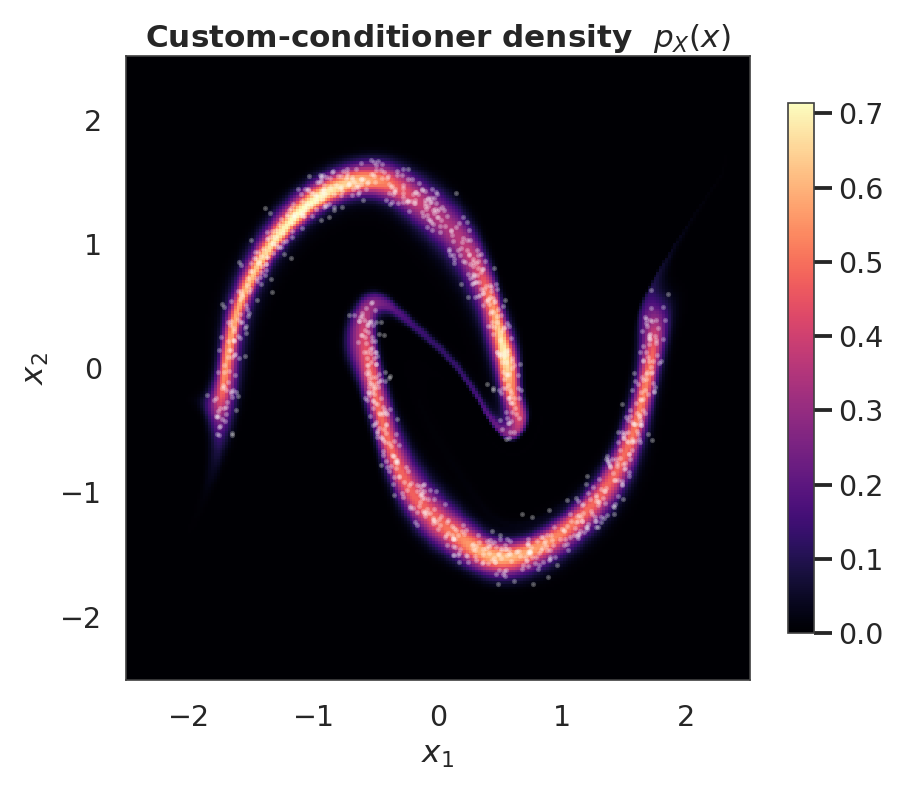

In [12]:
from gaussianization.gauss_keras import MixtureCDFCoupling, Householder
from gaussianization.gauss_keras.bijectors import GaussianizationFlow

D, D_B, K = 2, 1, 8


def make_residual_conditioner(d_b, num_components, hidden_width=32):
    inp = keras.layers.Input(shape=(D - d_b,))
    h = keras.layers.Dense(hidden_width, activation="tanh")(inp)
    h = keras.layers.Dense(hidden_width, activation="tanh")(h) + h
    out = keras.layers.Dense(
        3 * d_b * num_components,
        kernel_initializer="zeros",
        bias_initializer="zeros",
    )(h)
    return keras.Model(inp, out)


mask = np.array([True, False])
custom_layers = []
for _ in range(4):
    custom_layers.append(Householder(num_reflectors=2))
    custom_layers.append(
        MixtureCDFCoupling(
            mask=mask,
            conditioner=make_residual_conditioner(d_b=1, num_components=K),
            num_components=K,
        )
    )
    custom_layers.append(
        MixtureCDFCoupling(
            mask=~mask,
            conditioner=make_residual_conditioner(d_b=1, num_components=K),
            num_components=K,
        )
    )
flow_custom = GaussianizationFlow(custom_layers, input_dim=D)
_ = flow_custom(ops.convert_to_tensor(X[:4]))

flow_custom.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-3),
    loss=base_nll_loss,
)
_ = flow_custom.fit(X, X, batch_size=512, epochs=100, verbose=0)

log_px_custom = ops.convert_to_numpy(
    flow_custom.log_prob(ops.convert_to_tensor(pts))
).reshape(grid, grid)

fig, ax = plt.subplots(figsize=(8.5, 7))
pcm = ax.pcolormesh(xx, yy, np.exp(log_px_custom), cmap="magma", shading="auto")
ax.scatter(X[:1000, 0], X[:1000, 1], s=2, alpha=0.25, color="white")
ax.set_title("Custom-conditioner density  $p_X(x)$")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
style_axes(ax, aspect="equal")
fig.colorbar(pcm, ax=ax, shrink=0.85)
plt.show()

## Recap

- Coupling = one half conditions, the other is transformed. Mask-swap in the same block so both halves get touched.
- The same `MixtureOfGaussians` primitive drives both the unconditional marginal layer (notebook 01) and this layer — only difference is that the params now come from a network output instead of a learned per-dim lookup.
- Zero-initialising the conditioner's final Dense makes training stable from step 0 (the flow starts as the identity).
- `make_mlp_conditioner` (per-dim) vs `make_shared_mlp_conditioner` (tiled) trade off capacity against parameter count; custom architectures plug in cleanly as long as they output $3 \cdot d_b \cdot K$ floats.